In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import sys

In the following the string graph as exported from cytoscape is read into a undirected graph

In [3]:
# Load the network as an undirected graph
G = nx.read_graphml("../data/graphml_string.graphml").to_undirected()
# relable the nodes with the 'stringdb::canonical name' attribute
G = nx.relabel_nodes(G, nx.get_node_attributes(G, 'stringdb::canonical name'))

In [5]:
def generate_ego_network(id, radius):
    try:
        ego_graph = nx.ego_graph(G, id, radius=radius, undirected=True, center=True)
    except:
        print("The id is not in the graph")
        return 
    return ego_graph
    

In [32]:
from functools import partial
def generate_get_intersections(ego_dict):
  #generate a partial function which sets thte ego_dict of get_intersection
  return partial(get_intersections, ego_dict)

def get_intersections(ego_graphs, id1, id2):
  if id1 == id2:
    return -1
  try:
    #find the common nodes between the two ego networks
    common_nodes = set(ego_graphs[id1].nodes()).intersection(set(ego_graphs[id2].nodes()))
    #return the length of the common nodes
  except:
    #print("No ego graph found: {}, {}".format(id1, id2))
    return -1
  return len(common_nodes)


In [34]:
from functools import partial
def generate_get_jaccard_indes(ego_dict):
  #generate a partial function which sets thte ego_dict of get_intersection
  return partial(get_jaccard_index, ego_dict)

##calculate the jaccard index between the two ego networks
def get_jaccard_index(ego_graphs,id1,id2):
  if id1 == id2:
    return -1
  try:
    #find the common nodes between the two ego networks
    common_nodes = set(ego_graphs[id1].nodes()).intersection(set(ego_graphs[id2].nodes()))
    #find the union of the two ego networks
    union_nodes = set(ego_graphs[id1].nodes()).union(set(ego_graphs[id2].nodes()))
    #return the jaccard index
  except:
    #print("No ego graph found: {}, {}".format(id1, id2))
    return -1
  return len(common_nodes)/len(union_nodes)

In [8]:
allIDs = ["P49790", "Q9UMS4", "Q99459", "Q8WWY3", "P61978", "P57740", "P57740", "P14314", "P14314", "Q14498", "P49790", "P30050", "P48729", "Q7KZF4", "P12270", "O43447", "Q9GZT3", "Q9GZT3", "P11142", "P19387", "Q8N983", "Q9UBS4", "Q9NXW2", "P61421", "P51452", "Q9NPA0", "P62910", "P62910", "Q92841", "P30050", "P47914", "Q99805", "P62829", "Q6ZRV2", "P46782", "Q8NC56", "Q96EL3", "Q96DV4", "O75477", "Q8IYS2", "P20674", "P83731", "O15226", "P37108", "P37108", "Q5SW79", "O75940", "O95881", "Q96HY7", "P53597", "P42126", "Q06124", "Q13751", "P52789", "Q9H307", "Q13618", "Q13618", "P63279", "Q9ULU4", "Q8TCS8", "Q13263", "Q9UNF1", "Q9UBB4", "Q9UBT2", "Q9BTE3", "Q9BTE3", "O43752", "P52565", "Q9UBE0", "Q92922", "Q14008", "Q96PZ0", "Q9GZR2", "P62263", "P05387", "P78527", "P78527", "Q13586", "Q15369", "P31153", "P05141", "Q15067", "P63220", "Q9UNL2", "O95168", "Q9Y3E5", "Q9NRN7", "Q9UBT2", "P23193", "Q16850", "Q01518", "P07910", "P07910", "Q15102", "Q13492", "Q15370", "Q14566", "P37837", "P00568", "O95373", "P46013", "P30086", "P35580", "P35580", "O75347", "Q99829", "Q14157", "O43765"]

In [9]:
from multiprocessing import Pool


In [23]:
with Pool(processes=12) as pool:

  ego_dict_deg1 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [1]*len(allIDs)))))
  ego_dict_deg2 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [2]*len(allIDs)))))
  ego_dict_deg3 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [3]*len(allIDs)))))

The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph
The id is not in the graph


In [14]:
import itertools
# generate all unique pairs of IDs from the list
pairs = list(itertools.combinations(allIDs, 2))
print(len(pairs))


5778


In [36]:
def filter_lt0(vals):
  print("Pre: ",len(vals))
  filtered = [val for val in vals if val > 0]
  print("Post: ",len(filtered))
  return filtered

In [37]:
intersections1 = filter_lt0([get_intersections(ego_dict_deg1,*pair) for pair in pairs])
intersections2 = filter_lt0([get_intersections(ego_dict_deg2,*pair) for pair in pairs])
intersections3 = filter_lt0([get_intersections(ego_dict_deg3,*pair) for pair in pairs])
jaccard1 = filter_lt0([get_jaccard_index(ego_dict_deg1,*pair) for pair in pairs])
jaccard2 = filter_lt0([get_jaccard_index(ego_dict_deg2,*pair) for pair in pairs])
jaccard3 = filter_lt0([get_jaccard_index(ego_dict_deg3,*pair) for pair in pairs])

Pre:  5778
Post:  498
Pre:  5778
Post:  3940
Pre:  5778
Post:  4701
Pre:  5778
Post:  498
Pre:  5778
Post:  3940
Pre:  5778
Post:  4701


In [26]:
print(len(intersections1))
#filter out the -1 values
intersectionsFilter = [i for i in intersections if i >0]
print(max(intersectionsFilter))

5778
1037


In [52]:
import numpy as np

#function to calculate bins for the histogram using the Freedman-Diaconis rule
def freedman_diaconis(data):
  IQR = np.percentile(data, 75) - np.percentile(data, 25)
  bin_width = 2 * IQR * len(data) ** (-1/3)
  return int((max(data) - min(data))/bin_width)

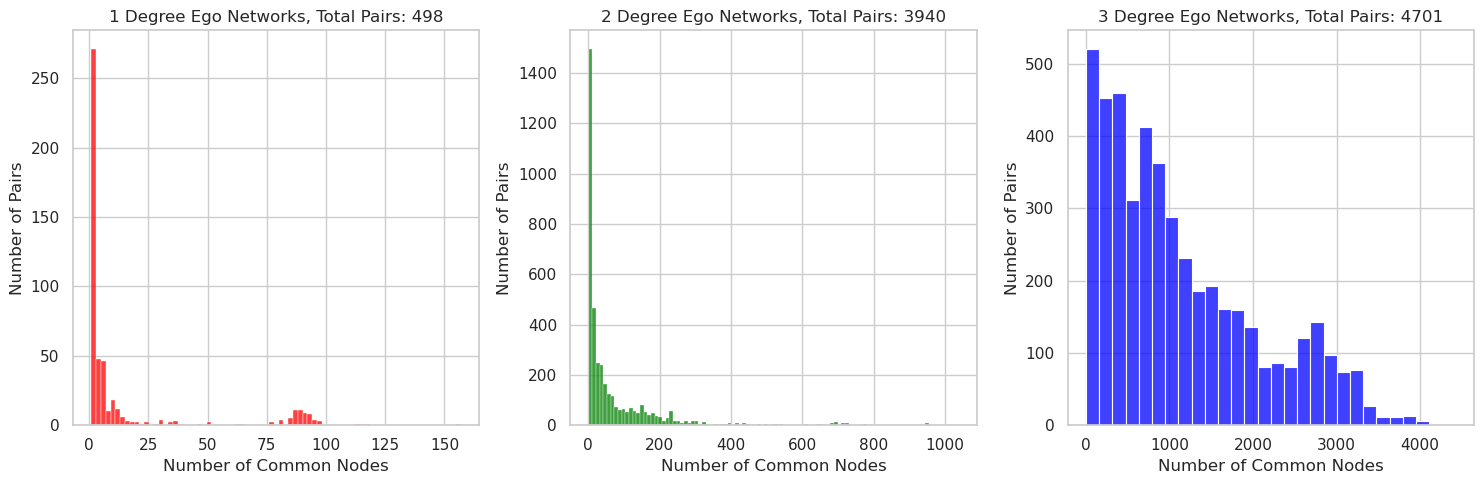

In [63]:
#draw the histograms of the intersection values for 1 degree, 2 degree, and 3 degree ego networks in faceted plots using seaborn the x-axis is the number of common nodes, and should be scaled to the maximum of each specific subplot, and the y-axis is the number of pairs of protein ego-graphs with that number of common nodes
import seaborn as sns
import matplotlib.pyplot as plt

#set the style
sns.set_style("whitegrid")

#plot the histograms
# calculate the number of bins for each plot using the Freedman-Diaconis rule

fig, axes = plt.subplots(1,3, figsize=(15,5), sharex=False)
sns.histplot(intersections1, ax=axes[0], bins=freedman_diaconis(intersections1), color="red")
sns.histplot(intersections2, ax=axes[1], bins=freedman_diaconis(intersections2), color="green")
sns.histplot(intersections3, ax=axes[2], bins=freedman_diaconis(intersections3), color="blue")
axes[0].set_title("1 Degree Ego Networks, Total Pairs: " + str(len(intersections1)))
axes[1].set_title("2 Degree Ego Networks, Total Pairs: " + str(len(intersections2)))
axes[2].set_title("3 Degree Ego Networks, Total Pairs: " + str(len(intersections3)))
axes[0].set_xlabel("Number of Common Nodes")
axes[1].set_xlabel("Number of Common Nodes")
axes[2].set_xlabel("Number of Common Nodes")
axes[0].set_ylabel("Number of Pairs")
axes[1].set_ylabel("Number of Pairs")
axes[2].set_ylabel("Number of Pairs")
plt.tight_layout()




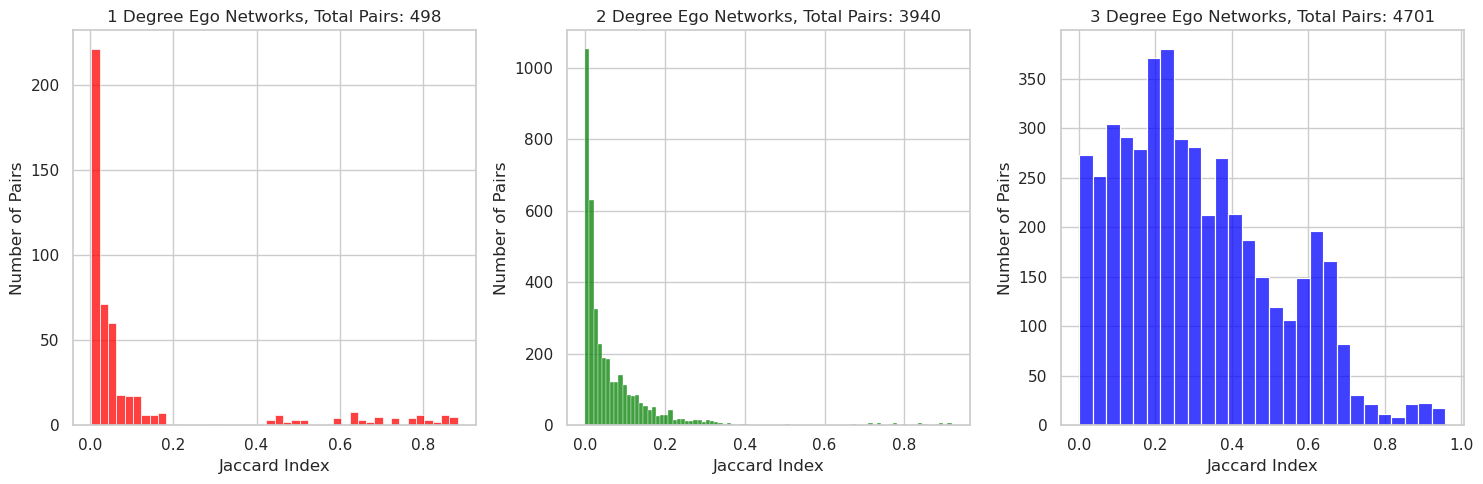

In [64]:
#draw the histograms of the intersection values for 1 degree, 2 degree, and 3 degree ego networks in faceted plots using seaborn the x-axis is the number of common nodes, and should be scaled to the maximum of each specific subplot, and the y-axis is the number of pairs of protein ego-graphs with that number of common nodes
import seaborn as sns
import matplotlib.pyplot as plt

#set the style
sns.set_style("whitegrid")

#plot the histograms
# calculate the number of bins for each plot using the Freedman-Diaconis rule

fig, axes = plt.subplots(1,3, figsize=(15,5), sharex=False)
sns.histplot(jaccard1, ax=axes[0], bins=freedman_diaconis(jaccard1), color="red")
sns.histplot(jaccard2, ax=axes[1], bins=freedman_diaconis(jaccard2), color="green")
sns.histplot(jaccard3, ax=axes[2], bins=freedman_diaconis(jaccard3), color="blue")
# add the size of the dataset to the plottitle
axes[0].set_title("1 Degree Ego Networks, Total Pairs: " + str(len(jaccard1)))
axes[1].set_title("2 Degree Ego Networks, Total Pairs: " + str(len(jaccard2)))
axes[2].set_title("3 Degree Ego Networks, Total Pairs: " + str(len(jaccard3)))
axes[0].set_xlabel("Jaccard Index")
axes[1].set_xlabel("Jaccard Index")
axes[2].set_xlabel("Jaccard Index")
axes[0].set_ylabel("Number of Pairs")
axes[1].set_ylabel("Number of Pairs")
axes[2].set_ylabel("Number of Pairs")
plt.tight_layout()




In [4]:
#given the two ids "P49790" and "Q9UMS4" generate two ego networks of depth for each of them
ego1 = nx.ego_graph(G, "P49790", radius=1, undirected=True, center=True)
ego2 = nx.ego_graph(G, "Q9UMS4", radius=1, undirected=True, center=True)

#find the common nodes between the two ego networks
common_nodes = set(ego1.nodes()).intersection(set(ego2.nodes()))

print("Common nodes between the two ego networks: ", common_nodes)


Common nodes between the two ego networks:  {'P62318', 'P62316', 'P62304', 'P62314', 'P11142', 'P62306', 'P14678'}


In [4]:
# import the customCircleLayout function from the customCircleLayout.py file
from customCircleLayout import customCircleLayout

customCircleLayout2
['Q99567', 'Q9Y6D9', 'P56524', 'Q8TD19', 'Q9BZY3', 'Q8NFH3', 'Q69YH5', 'Q8TEM1', 'P12270', 'O15504', 'O75694', 'P55735', 'Q14493', 'Q13257', 'Q53HL2', 'Q10570', 'P61970', 'Q7Z3B4', 'Q8N1F7', 'Q15796', 'P37198', 'Q9C0J8', 'O95067', 'Q8TDX7', 'P63165', 'Q9H814', 'E5RJF8', 'Q96F70', 'P34932', 'P84022', 'Q9UHI6', 'Q5TCJ3', 'Q9BTX1', 'Q9Y6J5', 'Q14974', 'P52292', 'P17066', 'O60318', 'Q9UPY3', 'P61956', 'Q16630', 'Q9H077', 'H3BLT4', 'Q9NQS7', 'Q9UBU9', 'P35658', 'Q96GD4', 'Q9UKX7', 'O95149', 'P20700', 'P78406', 'Q9BW27', 'Q9UKV8', 'Q9UKF6', 'Q92621', 'Q9UBN7', 'O15397', 'Q9H840', 'Q96HK7', 'O95639', 'O95757', 'O14980', 'Q9P2I0', 'P54652', 'P63279', 'Q12769', 'P41208', 'Q13547', 'P34931', 'Q53GS7', 'P11388', 'P57740', 'Q53FT3', 'H0Y8J7', 'Q8TEQ6', 'Q5SRE5', 'P06493', 'P38646', 'Q8WUM0', '6409', 'Q9NRG9', 'P46060', '2483', 'Q0VDF9', 'P49792', 'Q92797', 'O43301', 'Q9CZA2', 'P57678', 'Q8WXD5', 'P48723', 'Q13485', 'Q8NFH4', 'O43592', 'Q9NWZ8', 'Q92973', 'Q9NPA8', 'O14893', 'P1

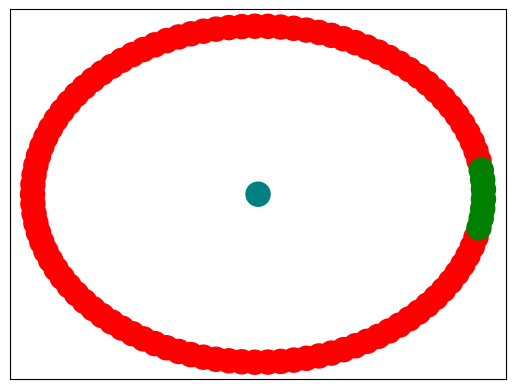

In [5]:
ego1_nodes = [n for n in ego1.nodes() if n not in common_nodes and n != "P49790"]

pos = customCircleLayout(ego1_nodes, list(common_nodes), 0, (0,0), 3)
pos = {**pos, **{'P49790': (0,0)}}
print(pos)
# draw the ego network of "P49790" with the common nodes in the direction of 135 degrees
G_new = nx.Graph()
G_new.add_nodes_from(ego1_nodes, color='red')
G_new.add_nodes_from(common_nodes, color='green')
G_new.add_nodes_from(["P49790"], color='teal')
print(G_new.nodes())
nx.draw_networkx_nodes(G_new, pos, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])




customCircleLayout2
['Q99567', 'Q9Y6D9', 'P56524', 'Q8TD19', 'Q9BZY3', 'Q8NFH3', 'Q69YH5', 'Q8TEM1', 'P12270', 'O15504', 'O75694', 'P55735', 'Q14493', 'Q13257', 'Q53HL2', 'Q10570', 'P61970', 'Q7Z3B4', 'Q8N1F7', 'Q15796', 'P37198', 'Q9C0J8', 'O95067', 'Q8TDX7', 'P63165', 'Q9H814', 'E5RJF8', 'Q96F70', 'P34932', 'P84022', 'Q9UHI6', 'Q5TCJ3', 'Q9BTX1', 'Q9Y6J5', 'Q14974', 'P52292', 'P17066', 'O60318', 'Q9UPY3', 'P61956', 'Q16630', 'Q9H077', 'H3BLT4', 'Q9NQS7', 'Q9UBU9', 'P35658', 'Q96GD4', 'Q9UKX7', 'O95149', 'P20700', 'P78406', 'Q9BW27', 'Q9UKV8', 'Q9UKF6', 'Q92621', 'Q9UBN7', 'O15397', 'Q9H840', 'Q96HK7', 'O95639', 'O95757', 'O14980', 'Q9P2I0', 'P54652', 'P63279', 'Q12769', 'P41208', 'Q13547', 'P34931', 'Q53GS7', 'P11388', 'P57740', 'Q53FT3', 'H0Y8J7', 'Q8TEQ6', 'Q5SRE5', 'P06493', 'P38646', 'Q8WUM0', '6409', 'Q9NRG9', 'P46060', '2483', 'Q0VDF9', 'P49792', 'Q92797', 'O43301', 'Q9CZA2', 'P57678', 'Q8WXD5', 'P48723', 'Q13485', 'Q8NFH4', 'O43592', 'Q9NWZ8', 'Q92973', 'Q9NPA8', 'O14893', 'P1

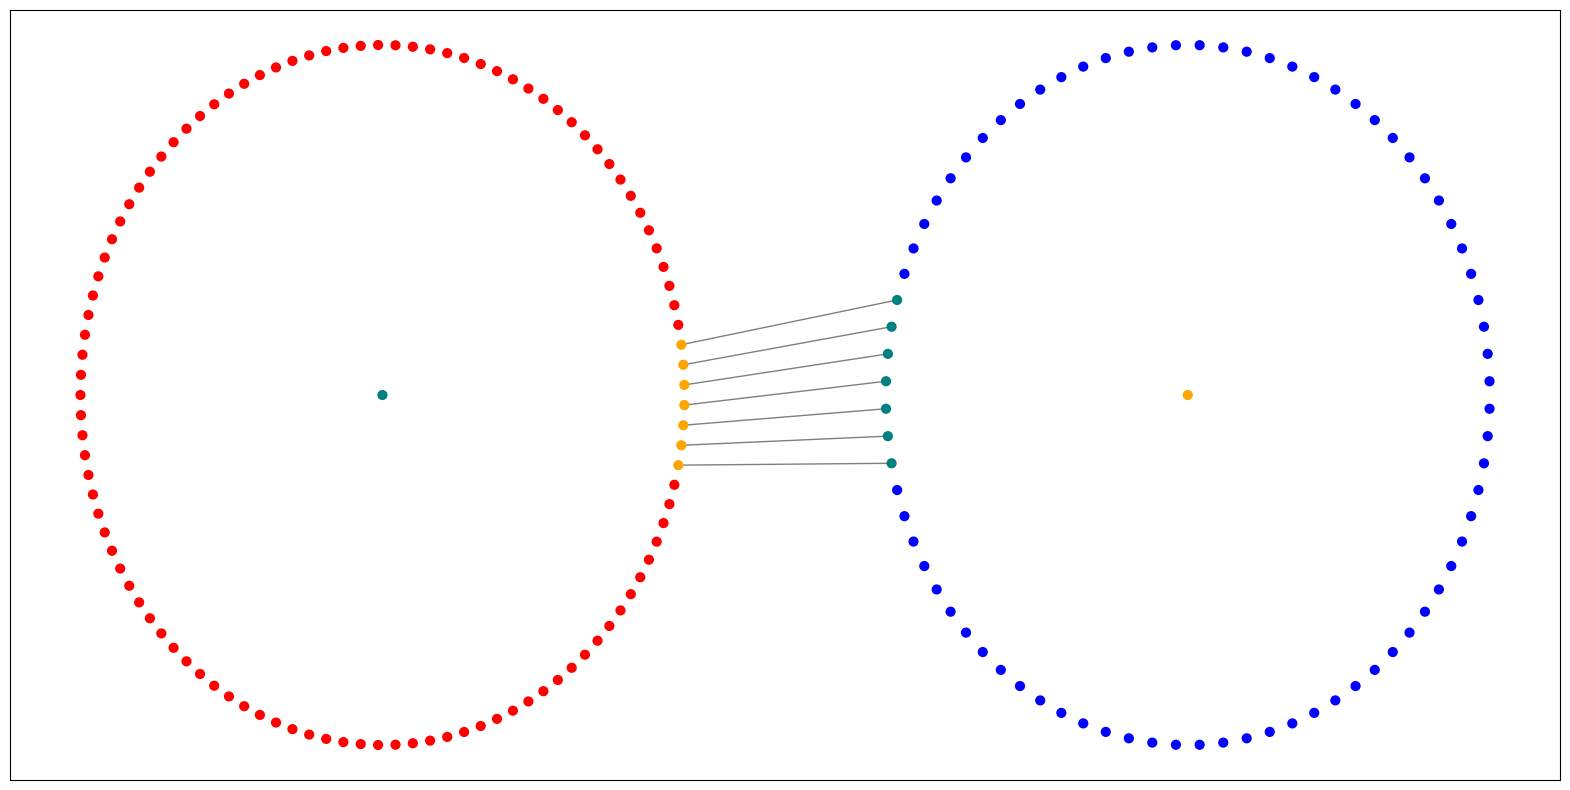

In [6]:
# layout ego1 and ego2 such that the node "P49790" and "Q9UMS4" is in the center and the other nodes are arranged around it in a circle
# the two circles should be arranged in a way that they do not overlap
# the nodes in the two circles should be colored differently
# the shared nodes should be drawen between the two circles

# create a new graph
G_new = nx.Graph()

ego1_nodes = ego1.nodes()
ego2_nodes = ego2.nodes()
#remove the common nodes and the center nodes from the two ego networks

ego1_nodes = [n for n in ego1_nodes if n != "P49790"]
ego2_nodes = [n for n in ego2_nodes if n != "Q9UMS4"]

ego1_notCommon = [n for n in ego1_nodes if n not in common_nodes and n != "P49790"]
ego2_notCommon = [n for n in ego2_nodes if n not in common_nodes and n != "Q9UMS4"]

# duplicate the common nodes in the two ego networks add ego1 and ego2 to the node names
ego1_common_nodes = [n+"_ego1" for n in common_nodes]
ego2_common_nodes = [n+"_ego2" for n in common_nodes]



# add the nodes from the two ego networks
G_new.add_nodes_from(ego1_notCommon, color='red')
G_new.add_nodes_from(ego2_notCommon, color='blue')

G_new.add_nodes_from(["P49790"], color='teal')
G_new.add_nodes_from(["Q9UMS4"], color='orange')

G_new.add_nodes_from(ego1_common_nodes, color='orange')
G_new.add_nodes_from(ego2_common_nodes, color='teal')

#add edges between the duplicated common nodes
for i, n in enumerate(common_nodes):
    G_new.add_edge(n+"_ego1", n+"_ego2")


# set the positions of the nodes
pos1 = customCircleLayout(ego1_notCommon, ego1_common_nodes , 0 ,(2, 2), 1.5, reverse=True)
pos2 = customCircleLayout(ego2_notCommon, ego2_common_nodes, 180 ,(6, 2), 1.5)

# set the positions of the center nodes
pos_center = {"P49790": (2, 2), "Q9UMS4": (6, 2)}

pos = {**pos1, **pos2, **pos_center}
print(pos)
# square figure
plt.figure(figsize=(20,10))

# draw the nodes
nx.draw_networkx_nodes(G_new, pos, node_size=40, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])
# draw the edges
nx.draw_networkx_edges(G_new, pos, width=1.0, alpha=0.5)
